In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

In [2]:
#With discharge
file_path = r'y_obs.csv'
y_obs = pd.read_csv(file_path, parse_dates=[0])
# Set the unnamed first column (dates) as the index
y_obs.set_index(y_obs.columns[0],inplace=True)
file_path = r'y_sim.csv'
y_sim = pd.read_csv(file_path, parse_dates=[0])
file_path = r'NSE.csv'
nse_disch = pd.read_csv(file_path)
# Set the unnamed first column (dates) as the index
y_sim.set_index(y_sim.columns[0],inplace=True)

In [3]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr

# Function to calculate precipitation indices for a single catchment
def calculate_precipitation_indices(series):
    # Initialize a dictionary to store precipitation indices
    indices = {}

    # Total precipitation amount averaged over all days
    indices['avgprcp'] = series.sum(skipna=True) / series.count()

    # Average precipitation amount for rainy days (precipitation > 1 mm)
    rainy_days = series[series > 1]
    indices['avgprcp_rainy'] = rainy_days.mean() if not rainy_days.empty else np.nan

    # Daily precipitation amount corresponding to the 90th percentile
    indices['r90p'] = series.quantile(0.9)

    # Daily precipitation amount corresponding to the 90th percentile of non-zero precipitation
    indices['r90p_1'] = series[series >= 1].quantile(0.90)

    # Daily precipitation amount corresponding to the 95th percentile
    indices['r95p'] = series.quantile(0.95)

    # Daily precipitation amount corresponding to the 95th percentile of non-zero precipitation
    indices['r95p_1'] = series[series >= 1].quantile(0.95)

    # 25th percentile of daily precipitation
    indices['r25p'] = series.quantile(0.25)

    # Maximum 1-day precipitation
    indices['rx1day'] = series.max()

    # Maximum 5-day precipitation
    indices['rx5day'] = series.rolling(window=5, min_periods=1).sum().max()

    # Number of days with precipitation ≥ 10 mm
    indices['r10mm'] = (series >= 10).sum()

    # Number of days with precipitation ≥ 20 mm
    indices['r20mm'] = (series >= 20).sum()

    # Number of wet days (precipitation ≥ 1 mm)
    indices['wetdays'] = (series >= 1).sum()

    # Number of very wet days (≥ 95th percentile of non-zero precipitation days)
    very_wet_threshold = series[series >= 1].quantile(0.95)
    indices['verywetdays'] = (series >= very_wet_threshold).sum()

    # Number of extremely wet days (≥ 99th percentile of non-zero precipitation days)
    extremely_wet_threshold = series[series >= 1].quantile(0.99)
    indices['extremewetdays'] = (series >= extremely_wet_threshold).sum()

    # Calculate RUNAB - Runs above and below the median
    median = series.median()
    series_ab = series.apply(lambda x: 'A' if x > median else 'B')
    runs = (series_ab != series_ab.shift(1)).sum()

    n1 = (series_ab == 'A').sum()
    n2 = (series_ab == 'B').sum()

    if n1 > 20 and n2 > 20:
        mu = (2 * n1 * n2) / (n1 + n2) + 1
        sigma = np.sqrt((2 * n1 * n2 * (2 * n1 * n2 - n1 - n2)) / ((n1 + n2) ** 2 * (n1 + n2 - 1)))
        z = abs(runs - mu) / sigma
        indices['RUNAB'] = z
    else:
        indices['RUNAB'] = np.nan  # Set to NaN if not enough data

    # Calculate Spearman lag-1 autocorrelation for ranks
    ranks = series.rank()
    ranks_lag1 = ranks.shift(1)
    valid_idx = ranks_lag1.notna() & ranks.notna()
    spearman_corr, _ = spearmanr(ranks[valid_idx], ranks_lag1[valid_idx])
    indices['spearman_lag1'] = spearman_corr

    return pd.Series(indices)

In [4]:
# Apply the precipitation indices function to each catchment column for y_obs
results_era5 = y_obs.apply(calculate_precipitation_indices, axis=0).T
results_era5['Catchment'] = results_era5.index

# Apply the precipitation indices function to each catchment column for y_sim
results_y_sim = y_sim.apply(calculate_precipitation_indices, axis=0).T
results_y_sim['Catchment'] = results_y_sim.index



C:\Users\ashis\AppData\Local\Temp\ipykernel_31012\2784419418.py:11: RuntimeWarning: invalid value encountered in scalar divide
  indices['avgprcp'] = series.sum(skipna=True) / series.count()
c:\Users\ashis\anaconda3\envs\new_env\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\ashis\AppData\Local\Temp\ipykernel_31012\2784419418.py:11: RuntimeWarning: invalid value encountered in scalar divide
  indices['avgprcp'] = series.sum(skipna=True) / series.count()
c:\Users\ashis\anaconda3\envs\new_env\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\ashis\AppData\Local\Temp\ipykernel_31012\2784419418.py:11: RuntimeWarning: invalid value encountered in scalar divide
  indices['avgprcp'] = series.sum(skipna=True) / series.count()
c:\Users\ashis\anaconda3\envs\new_env\lib\site-packag

In [5]:
# Rename columns for clarity before merging
results_era5_renamed = results_era5.rename(columns=lambda x: f"era5_{x}")
results_y_sim_renamed = results_y_sim.rename(columns=lambda x: f"y_sim_{x}")

# Merge the DataFrames
combined_results = pd.merge(results_era5_renamed, results_y_sim_renamed, left_index=True, right_index=True)

# Reset index if needed, for easier manipulation
combined_results.reset_index(inplace=True)

# Display the merged DataFrame
print(combined_results.head())

          index  era5_avgprcp  era5_avgprcp_rainy  era5_r90p  era5_r90p_1  \
0  GRDC_6140100      2.383335            5.107542      6.770       11.283   
1  GRDC_6140101      2.279040            5.005228      6.540       10.670   
2  GRDC_6140120      2.285547            5.252399      6.822       11.150   
3  GRDC_6140130      3.103167            6.037563      9.022       12.608   
4  GRDC_6140140      2.998241            5.969102      8.710       12.456   

   era5_r95p  era5_r95p_1  era5_r25p  era5_rx1day  era5_rx5day  ...  \
0     10.571      14.7105       0.07        46.24       101.48  ...   
1      9.980      14.6275       0.06        46.73        97.38  ...   
2     10.170      14.8910       0.04        60.86       104.07  ...   
3     12.545      16.6475       0.08        53.13       112.26  ...   
4     12.312      16.2920       0.06        59.22       107.06  ...   

   y_sim_rx1day  y_sim_rx5day  y_sim_r10mm  y_sim_r20mm  y_sim_wetdays  \
0     38.956806     80.987060       

Plotting using shapefiles

In [6]:
import pandas as pd
import geopandas as gpd

# Read the shapefiles
shapefile1 = gpd.read_file(r"shapefiles\camelsgb_basin_shapes.shp")
shapefile2 = gpd.read_file(r"shapefiles\grdc_basin_shapes.shp")

# Merge the shapefiles
merged = gpd.GeoDataFrame(pd.concat([shapefile1, shapefile2], ignore_index=True))

# Save to a GeoPackage
#merged.to_file("catchments.gpkg", layer='merged_layer', driver="GPKG")

In [7]:
merged

,gauge_id,geometry
0,camelsgb_10002,"POLYGON ((-1.83259 57.52677, -1.83343 57.52677..."
1,camelsgb_10003,"POLYGON ((-2.08934 57.36359, -2.08933 57.36314..."
2,camelsgb_1001,"POLYGON ((-3.26666 58.47607, -3.26665 58.47562..."
3,camelsgb_11001,"POLYGON ((-2.1875 57.21841, -2.1875 57.21774, ..."
4,camelsgb_11003,"POLYGON ((-2.71701 57.24233, -2.717 57.24211, ..."
...,...,...
5760,GRDC_6948120,"POLYGON ((8.59583 46.5, 8.6125 46.5, 8.6125 46..."
5761,GRDC_6948150,"POLYGON ((9.05833 46.11667, 9.075 46.11667, 9...."
5762,GRDC_6948360,"POLYGON ((8.475 46.38333, 8.49583 46.38333, 8...."
5763,GRDC_6948520,"POLYGON ((9.16667 46.20417, 9.17917 46.20417, ..."


In [8]:
combined_results

,index,era5_avgprcp,era5_avgprcp_rainy,era5_r90p,era5_r90p_1,era5_r95p,era5_r95p_1,era5_r25p,era5_rx1day,era5_rx5day,...,y_sim_rx1day,y_sim_rx5day,y_sim_r10mm,y_sim_r20mm,y_sim_wetdays,y_sim_verywetdays,y_sim_extremewetdays,y_sim_RUNAB,y_sim_spearman_lag1,y_sim_Catchment
0,GRDC_6140100,2.383335,5.107542,6.770,11.283,10.571,14.7105,0.070,46.24,101.48,...,38.956806,80.987060,139.0,20.0,3084.0,155.0,31.0,25.684498,0.494209,GRDC_6140100
1,GRDC_6140101,2.279040,5.005228,6.540,10.670,9.980,14.6275,0.060,46.73,97.38,...,34.994934,80.089094,142.0,17.0,3095.0,155.0,31.0,25.792586,0.496111,GRDC_6140101
2,GRDC_6140120,2.285547,5.252399,6.822,11.150,10.170,14.8910,0.040,60.86,104.07,...,42.147690,91.743918,168.0,32.0,3074.0,154.0,31.0,26.387073,0.498406,GRDC_6140120
3,GRDC_6140130,3.103167,6.037563,9.022,12.608,12.545,16.6475,0.080,53.13,112.26,...,32.252823,87.811171,202.0,25.0,3582.0,180.0,36.0,27.522000,0.522959,GRDC_6140130
4,GRDC_6140140,2.998241,5.969102,8.710,12.456,12.312,16.2920,0.060,59.22,107.06,...,59.496700,120.113126,223.0,34.0,3596.0,180.0,36.0,25.495343,0.495741,GRDC_6140140
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1799,camelsgb_95001,4.257740,6.048317,10.612,12.370,13.832,15.7700,0.605,44.85,92.40,...,39.432953,97.508687,358.0,38.0,2889.0,145.0,29.0,48.372312,0.684334,camelsgb_95001
1800,camelsgb_96001,3.211281,4.888298,8.106,9.786,10.521,12.6240,0.440,51.77,99.46,...,34.980507,74.611440,153.0,9.0,2547.0,128.0,26.0,43.993418,0.603794,camelsgb_96001
1801,camelsgb_96002,3.436948,5.118097,8.600,10.280,11.531,13.3880,0.450,50.82,96.91,...,41.231068,91.372848,229.0,23.0,2624.0,132.0,27.0,47.077146,0.677921,camelsgb_96002
1802,camelsgb_96004,3.827994,5.578480,9.530,11.311,12.420,14.4800,0.540,51.14,97.49,...,40.726620,105.490304,414.0,44.0,2864.0,144.0,29.0,42.081506,0.584818,camelsgb_96004


In [9]:
# Ensure the 'gauge_id' column and 'index' column are in the correct type for merging
merged['gauge_id'] = merged['gauge_id'].astype(str)
combined_results['index'] = combined_results['index'].astype(str)

# Merge the GeoDataFrame with the DataFrame
merged = merged.merge(combined_results, left_on='gauge_id', right_on='index', how='left')

# Optionally, drop the 'index' column if it's no longer needed
merged = merged.drop(columns=['index'])

In [10]:
merged

,gauge_id,geometry,era5_avgprcp,era5_avgprcp_rainy,era5_r90p,era5_r90p_1,era5_r95p,era5_r95p_1,era5_r25p,era5_rx1day,...,y_sim_rx1day,y_sim_rx5day,y_sim_r10mm,y_sim_r20mm,y_sim_wetdays,y_sim_verywetdays,y_sim_extremewetdays,y_sim_RUNAB,y_sim_spearman_lag1,y_sim_Catchment
0,camelsgb_10002,"POLYGON ((-1.83259 57.52677, -1.83343 57.52677...",2.415545,4.370326,6.442,8.815,9.063,12.0175,0.20,39.10,...,33.826702,62.872073,137.0,9.0,2176.0,109.0,22.0,40.354619,0.514490,camelsgb_10002
1,camelsgb_10003,"POLYGON ((-2.08934 57.36359, -2.08933 57.36314...",2.393539,4.433754,6.412,9.124,9.301,11.9410,0.17,43.40,...,31.164540,59.009170,123.0,9.0,2107.0,106.0,22.0,42.019832,0.549823,camelsgb_10003
2,camelsgb_1001,"POLYGON ((-3.26666 58.47607, -3.26665 58.47562...",2.638235,4.345660,6.812,8.680,9.281,11.1750,0.31,48.13,...,30.127350,70.390346,148.0,11.0,2442.0,123.0,25.0,43.068300,0.601983,camelsgb_1001
3,camelsgb_11001,"POLYGON ((-2.1875 57.21841, -2.1875 57.21774, ...",2.607109,4.712885,7.020,9.672,9.950,13.1020,0.19,43.18,...,34.288467,67.310096,116.0,9.0,2323.0,117.0,24.0,40.539642,0.537659,camelsgb_11001
4,camelsgb_11003,"POLYGON ((-2.71701 57.24233, -2.717 57.24211, ...",2.825846,5.018296,7.680,10.493,10.810,13.5905,0.20,39.63,...,30.315058,62.839667,112.0,7.0,2460.0,123.0,25.0,40.508805,0.520300,camelsgb_11003
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5760,GRDC_6948120,"POLYGON ((8.59583 46.5, 8.6125 46.5, 8.6125 46...",5.092999,9.319686,13.210,22.524,24.115,35.6600,0.12,116.84,...,80.301540,193.118440,710.0,249.0,3383.0,170.0,34.0,29.531619,0.541526,GRDC_6948120
5761,GRDC_6948150,"POLYGON ((9.05833 46.11667, 9.075 46.11667, 9....",4.582462,10.379814,13.292,27.220,24.870,38.1900,0.01,101.37,...,50.514717,150.431605,630.0,169.0,2955.0,148.0,30.0,33.305182,0.567723,GRDC_6948150
5762,GRDC_6948360,"POLYGON ((8.475 46.38333, 8.49583 46.38333, 8....",5.182559,9.034104,13.752,20.940,22.940,32.1210,0.16,102.92,...,80.310220,181.966966,793.0,253.0,3544.0,178.0,36.0,29.965986,0.552706,GRDC_6948360
5763,GRDC_6948520,"POLYGON ((9.16667 46.20417, 9.17917 46.20417, ...",4.004656,8.906632,11.670,22.560,20.752,32.3525,0.02,97.68,...,68.943230,177.935420,670.0,224.0,3148.0,158.0,32.0,32.246413,0.571184,GRDC_6948520


In [12]:
pip install cartopy 

   ---------------------------------------- 0.0/10.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.9 MB ? eta -:--:--
    --------------------------------------- 0.3/10.9 MB ? eta -:--:--
   - -------------------------------------- 0.5/10.9 MB 1.3 MB/s eta 0:00:09
   -- ------------------------------------- 0.8/10.9 MB 1.4 MB/s eta 0:00:08
   ---- ----------------------------------- 1.3/10.9 MB 1.5 MB/s eta 0:00:07
   ----- ---------------------------------- 1.6/10.9 MB 1.5 MB/s eta 0:00:07
   ----- ---------------------------------- 1.6/10.9 MB 1.5 MB/s eta 0:00:07
   ------ --------------------------------- 1.8/10.9 MB 1.2 MB/s eta 0:00:08
   ------ --------------------------------- 1.8/10.9 MB 1.2 MB/s eta 0:00:08
   ------ --------------------------------- 1.8/10.9 MB 1.2 MB/s eta 0:00:08
   ------ --------------------------------- 1.8/10.9 MB 1.2 MB/s eta 0:00:08
   ------ --------------------------------- 1.8/10.9 MB 1.2 MB/s eta 0:00:08
   ------- ---------

In [13]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.patches import Patch
from matplotlib.collections import PatchCollection

C:\Users\ashis\AppData\Local\Temp\ipykernel_31012\572008342.py:10: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_cleaned['area'] = gdf_cleaned.geometry.area
c:\Users\ashis\anaconda3\envs\new_env\lib\site-packages\geopandas\geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
C:\Users\ashis\AppData\Local\Temp\ipykernel_31012\572008342.py:33: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  c

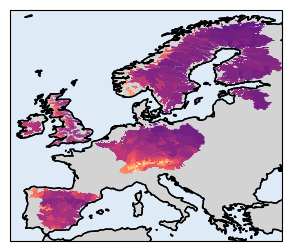

In [14]:
def plot_european_map_polygons_area(gdf, index_column, extent, cmap_color, vmin=None, vmax=None):
    # Clean the GeoDataFrame by dropping rows with missing values in the specified column
    gdf_cleaned = gdf.dropna(subset=[index_column])
    
    # Ensure the GeoDataFrame is in the correct CRS
    if gdf_cleaned.crs != "EPSG:4326":
        gdf_cleaned = gdf_cleaned.to_crs("EPSG:4326")
    
    # Calculate area and add it as a new column for sorting
    gdf_cleaned['area'] = gdf_cleaned.geometry.area
    
    # Sort the GeoDataFrame by area, smallest first
    gdf_cleaned = gdf_cleaned.sort_values(by='area',ascending=False)

    fig = plt.figure(figsize=(4.5, 3))
    # Change the projection to Lambert Conformal Conic for better representation of Europe
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

    ax.set_extent(extent, crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.LAND, color="lightgrey")
    ax.add_feature(cfeature.OCEAN, color='#deebf7')
    ax.add_feature(cfeature.COASTLINE)
    
    # Get the minimum and maximum values of the index column for custom colormap limits
    if vmin is None:
        vmin = gdf_cleaned[index_column].min()
    if vmax is None:
        vmax = gdf_cleaned[index_column].max()
    
    # Create a colormap and normalization
    norm = colors.Normalize(vmin=vmin, vmax=vmax)
    cmap = cm.get_cmap(cmap_color)
    
    # Plot each polygon, smallest area last (on top)
    for idx, row in gdf_cleaned.iterrows():
        ax.add_geometries([row.geometry], crs=ccrs.PlateCarree(), 
                          facecolor=cmap(norm(row[index_column])), 
                          edgecolor='white', linewidth=0.0001)

    # Create a ScalarMappable and add the colorbar
    #sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    #sm._A = []  # Dummy array for the ScalarMappable
    
    #cbar = plt.colorbar(sm, ax=ax, orientation='vertical', fraction=0.02, pad=0.04,shrink=0.6, extend='both')
    #cbar.set_label(index_column)

    ax.coastlines()

    plt.savefig(index_column+'.jpeg',dpi=1200)
    plt.show()
    

# Assuming 'merged' is your merged GeoDataFrame and 'index_column' is the column you want to plot
index_column = 'era5_avgprcp_rainy'  # Replace with your actual column name
extent = [-11.5, 32, 35, 72]   # Define the extent for the European map (min_lon, max_lon, min_lat, max_lat)
cmap_color = 'magma'  # Choose a colormap

# Call the function to plot the map
plot_european_map_polygons_area(merged, index_column, extent, cmap_color, vmin=1, vmax=10)

C:\Users\ashis\AppData\Local\Temp\ipykernel_31012\572008342.py:10: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_cleaned['area'] = gdf_cleaned.geometry.area
c:\Users\ashis\anaconda3\envs\new_env\lib\site-packages\geopandas\geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
C:\Users\ashis\AppData\Local\Temp\ipykernel_31012\572008342.py:33: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  c

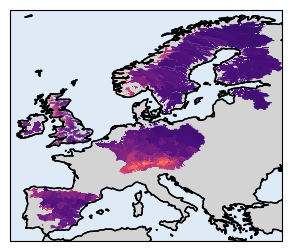

In [16]:
# Specify the index column to plot
index_column = 'y_sim_avgprcp_rainy'  # Replace 'NSE' with the name of your index column

# Plot the world map
plot_european_map_polygons_area(merged, index_column, extent, cmap_color, vmin=1, vmax=10)

C:\Users\ashis\AppData\Local\Temp\ipykernel_31012\572008342.py:10: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_cleaned['area'] = gdf_cleaned.geometry.area
c:\Users\ashis\anaconda3\envs\new_env\lib\site-packages\geopandas\geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
C:\Users\ashis\AppData\Local\Temp\ipykernel_31012\572008342.py:33: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  c

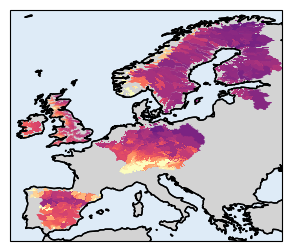

In [17]:
# Specify the index column to plot
index_column = 'era5_r95p_1'  # Replace 'NSE' with the name of your index column

# Plot the world map
plot_european_map_polygons_area(merged, index_column, extent, cmap_color, vmin=4, vmax=22)

C:\Users\ashis\AppData\Local\Temp\ipykernel_31012\572008342.py:10: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_cleaned['area'] = gdf_cleaned.geometry.area
c:\Users\ashis\anaconda3\envs\new_env\lib\site-packages\geopandas\geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
C:\Users\ashis\AppData\Local\Temp\ipykernel_31012\572008342.py:33: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  c

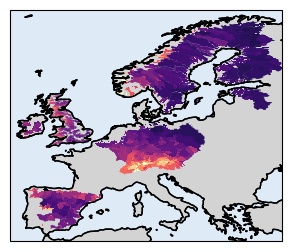

In [18]:
index_column = 'y_sim_r95p_1'
# Plot the world map
plot_european_map_polygons_area(merged, index_column, extent, cmap_color, vmin=4, vmax=22)

C:\Users\ashis\AppData\Local\Temp\ipykernel_31012\572008342.py:10: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_cleaned['area'] = gdf_cleaned.geometry.area
c:\Users\ashis\anaconda3\envs\new_env\lib\site-packages\geopandas\geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
C:\Users\ashis\AppData\Local\Temp\ipykernel_31012\572008342.py:33: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  c

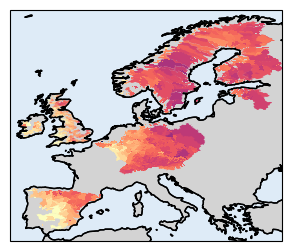

In [19]:
index_column = 'y_sim_spearman_lag1'
plot_european_map_polygons_area(merged, index_column, extent, cmap_color, vmin=0.2, vmax=0.7)

C:\Users\ashis\AppData\Local\Temp\ipykernel_31012\572008342.py:10: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_cleaned['area'] = gdf_cleaned.geometry.area
c:\Users\ashis\anaconda3\envs\new_env\lib\site-packages\geopandas\geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
C:\Users\ashis\AppData\Local\Temp\ipykernel_31012\572008342.py:33: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  c

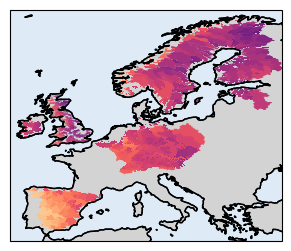

In [20]:
index_column = 'era5_spearman_lag1'
plot_european_map_polygons_area(merged, index_column, extent, cmap_color, vmin=0.2, vmax=0.7)